# asymptotics — Introduction

**asymptotics** is a semi-automated perturbation theory toolkit built on SymPy.

No symbol declarations needed — just write your equation as a string:

```python
from asymptotics import AlgebraicEquation

eq  = AlgebraicEquation("x**3 + eps*x - 1", dependent="x", small_param="eps")
sol = eq.expand_regular(order=3)
sol.show()
```

For coupled systems:

```python
from asymptotics import AlgebraicSystem

sys = AlgebraicSystem(
    equations   = ["x**2 + eps*y - 1", "y**2 + eps*x - 1"],
    dependents  = ["x", "y"],
    small_param = "eps",
)
sol = sys.expand_regular(order=3)
sol.show()
```

In [1]:
from asymptotics import AlgebraicEquation, AlgebraicSystem
%config InlineBackend.figure_format = 'svg'

---
## Part 1 — Single equations

### 1.1 The simplest possible example

$$x - 1 + \varepsilon = 0$$

The exact solution is $x = 1 - \varepsilon$. Perturbation theory should recover this exactly.

In [2]:
eq  = AlgebraicEquation("x - 1 + eps", dependent="x", small_param="eps")
sol = eq.expand_regular(order=2)
sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
sol.to_latex()

% Regular perturbation — algebraic

% Composite expansion

\begin{align}
  x(\varepsilon) &= 1 - \varepsilon + \mathcal{O}(\varepsilon^{3})
\end{align}


'% Regular perturbation — algebraic\n\n% Composite expansion\n\n\\begin{align}\n  x(\\varepsilon) &= 1 - \\varepsilon + \\mathcal{O}(\\varepsilon^{3})\n\\end{align}'

### 1.2 The classic cubic

$$x^3 + \varepsilon x - 1 = 0$$

In [4]:
eq2  = AlgebraicEquation("a*x**3 + eps*x - b", dependent="x", small_param="eps")
sol = eq2.expand_regular(order=3)
sol.show()

  ⚠️  symbolic parameters detected: {'a', 'b'}
     Provide values at eval/compare time:
     sol.eval(eps=0.1, params={'a': value, 'b': value})


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
sol.eval(eps=0.1,params={'a': 0.1,'b':0.23})

1.0705626400058113

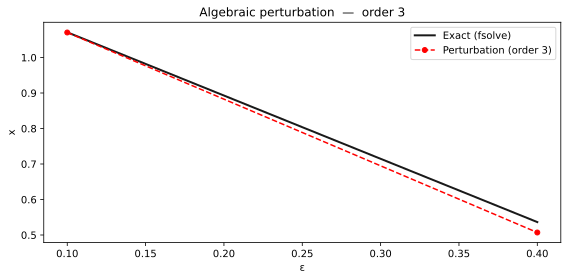

In [6]:
sol.compare_numeric(eps=[0.1,0.4],params={'a': 0.1,'b':0.23});

### 1.3 Inspecting intermediate steps

Every step is stored on the solution object.

In [7]:
eq  = AlgebraicEquation("x**3 + eps*x - 1", dependent="x", small_param="eps")
sol = eq.expand_regular(order=3)

sol.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 1.4 Root selection

$$x^2 + \varepsilon x - 1 = 0$$

Two real branches — use `root_hint` to choose.

In [8]:
eq_pos = AlgebraicEquation("x**2 + eps*x - 1", dependent="x", small_param="eps")
eq_neg = AlgebraicEquation("x**2 + eps*x - 1", dependent="x", small_param="eps", root_hint=-1)

sol_pos = eq_pos.expand_regular(order=3)
sol_neg = eq_neg.expand_regular(order=3)

print("Positive branch:")
sol_pos.show()
print("\nNegative branch:")
sol_neg.show()

Positive branch:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

{'eps': array([0.1, 0.2, 0.3]),
 'perturbation': array([0.95125, 0.905  , 0.86125]),
 'numerical': array([0.95124922, 0.90498756, 0.86118742]),
 'fig': <Figure size 800x400 with 1 Axes>}

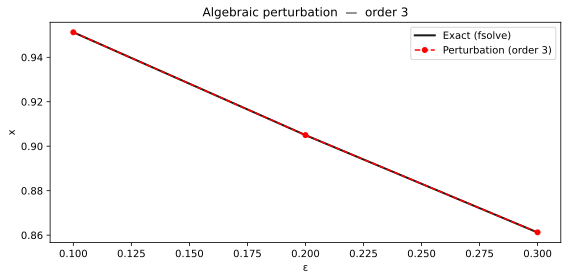

In [9]:
sol_pos.compare_numeric(eps=[0.1,0.2,0.3])

In [10]:
sol_pos.eval(eps=0.1)
sol_neg.eval(eps=0.1)

-1.05125

---
## Part 2 — Coupled systems

### 2.1 Symmetric algebraic system

$$x^2 + \varepsilon y - 1 = 0, \qquad y^2 + \varepsilon x - 1 = 0$$

By symmetry, $x(\varepsilon) = y(\varepsilon)$.

In [11]:
sys = AlgebraicSystem(
    equations   = ["x**2 + eps*y - b", "a*y**2 + eps*x - 1"],
    dependents  = ["x", "y"],
    small_param = "eps")

sol = sys.expand_regular(order=3)
sol.show()

In [12]:
sol.eval(eps=[0.1,0.2,0.3], params={'a':0.1, 'b':0.1})

{'x': array([ -1.05378625,  -4.76621171, -15.20312915]),
 'y': array([-3.22844557, -3.07697429, -2.33290132])}

{'eps': array([0.1]),
 'results': {'x': array([-1.05378625]), 'y': array([-3.22844557])},
 'fig': <Figure size 1000x400 with 2 Axes>}

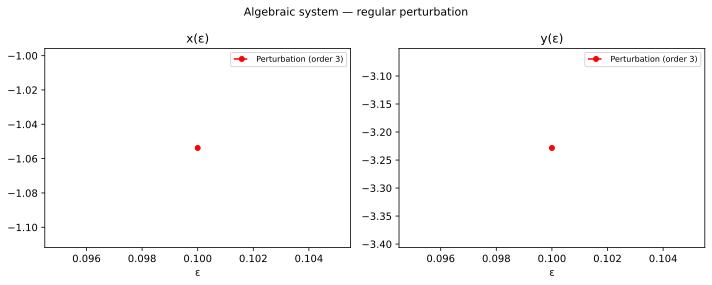

In [13]:
sol.compare_numeric(eps=0.1,params={'a':0.1, 'b':0.1})

In [14]:
sol.show()

### 2.2 Asymmetric system

$$x + \varepsilon y^2 - 1 = 0, \qquad y + \varepsilon x - 2 = 0$$

Unperturbed: $x_0 = 1$, $y_0 = 2$.

In [15]:
sys = AlgebraicSystem(
    equations   = ["x + eps*y**2 - 1", "y + eps*x - 2"],
    dependents  = ["x", "y"],
    small_param = "eps")

sol = sys.expand_regular(order=3)
sol.show()

### 2.3 Three-variable system

$$x + \varepsilon y - 1 = 0, \qquad y + \varepsilon z - 2 = 0, \qquad z + \varepsilon x - 3 = 0$$

In [16]:
sys = AlgebraicSystem(
    equations   = ["x + eps*y - 1", "y + eps*z - 2", "z + eps*x - 3"],
    dependents  = ["x", "y", "z"],
    small_param = "eps")

sol = sys.expand_regular(order=3)
sol.show()

---
## API quick reference

```python
from asymptotics import AlgebraicEquation, AlgebraicSystem

# Single equation
eq  = AlgebraicEquation("f(x, eps)", dependent="x", small_param="eps")
eq  = AlgebraicEquation("...", dependent="x", small_param="eps", root_hint=-1)
sol = eq.expand_regular(order=3)
sol.show()                    # full LaTeX hierarchy
sol.show(orders=[0, 1])       # specific orders
sol.expansion                 # SymPy Expr
sol.small_param               # the eps symbol
sol[k].equation               # Eq at order k
sol[k].solution               # value of x_k
sol.eval(eps=0.1)             # numerical evaluation
sol.compare_numeric(eps=[0.1, 0.5, 1.0])  # plot vs numerical root
sol.to_latex()                # LaTeX string

# Coupled system
sys = AlgebraicSystem(
    equations   = ["f1", "f2"],
    dependents  = ["x", "y"],
    small_param = "eps",
)
sol = sys.expand_regular(order=3)
sol.show()                    # all variables
sol["x"].expansion            # composite for x
sol["x"][k].solution          # x_k
sol["y"].show()               # hierarchy for y only
sol.eval(eps=0.1)             # numerical evaluation
sol.compare_numeric(eps=0.1)  # plot vs numerical solution
sol.to_latex()                # LaTeX string
```